In [ ]:
import numpy as pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv("/content/layoffs.csv")

In [ ]:
data.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Kraken,SF Bay Area,150.0,5/15/2026,NaN,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,5/15/2026
1,Innovaccer,SF Bay Area,340.0,5/14/2026,NaN,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,5/16/2026
2,Dune,"Oslo, Non-U.S.",NaN,5/14/2026,0.25,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79.0,Norway,5/15/2026
3,Gambling.com Group,"Dublin, Non-U.S.",NaN,5/14/2026,NaN,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276.0,Ireland,5/15/2026
4,Cisco,SF Bay Area,4000.0,5/13/2026,0.05,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2.0,United States,5/13/2026


In [ ]:
data.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [ ]:
data.shape

(4411, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4411 non-null   object 
 1   location             4410 non-null   object 
 2   total_laid_off       2889 non-null   float64
 3   date                 4411 non-null   object 
 4   percentage_laid_off  2777 non-null   float64
 5   industry             4409 non-null   object 
 6   source               4408 non-null   object 
 7   stage                4406 non-null   object 
 8   funds_raised         3902 non-null   float64
 9   country              4409 non-null   object 
 10  date_added           4411 non-null   object 
dtypes: float64(3), object(8)
memory usage: 379.2+ KB


In [ ]:
for col in data.columns:
  print(f"{col} -> {data[col][0]}")

company -> Kraken
location -> SF Bay Area
total_laid_off -> 150.0
date -> 5/15/2026
percentage_laid_off -> nan
industry -> Crypto
source -> https://www.bloomberg.com/news/articles/2026-05-15/kraken-cuts-150-workers-after-deploying-ai-ipo-may-slip-to-2027
stage -> Unknown
funds_raised -> 134.0
country -> United States
date_added -> 5/15/2026


In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0
location,1
total_laid_off,1522
percentage_laid_off,1634
industry,2
source,3
stage,5
funds_raised,509
country,2


In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data["date_added"] = pd.to_datetime(data["date_added"])

In [ ]:
data.describe()

,total_laid_off,date,percentage_laid_off,funds_raised,date_added
count,2889.000000,4411,2777.000000,3902.000000,4411
mean,316.433368,2023-02-13 09:55:27.408750848,0.293337,858.274192,2023-02-24 04:30:18.363183104
min,3.000000,2020-03-11 00:00:00,0.000000,0.700000,2020-03-28 00:00:00
25%,40.000000,2022-07-18 12:00:00,0.100000,55.000000,2022-07-26 00:00:00
50%,90.000000,2023-02-02 00:00:00,0.170000,175.000000,2023-02-08 00:00:00
75%,200.000000,2024-01-07 12:00:00,0.330000,482.750000,2024-01-12 00:00:00
max,30000.000000,2026-05-15 00:00:00,1.000000,121900.000000,2026-05-16 00:00:00
std,1200.433497,NaN,0.303406,4570.890341,NaN


data.duplicated().sum()

In [ ]:
data.drop_duplicates()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Kraken,SF Bay Area,150.0,2026-05-15,NaN,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,2026-05-15
1,Innovaccer,SF Bay Area,340.0,2026-05-14,NaN,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,2026-05-16
2,Dune,"Oslo, Non-U.S.",NaN,2026-05-14,0.25,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79.0,Norway,2026-05-15
3,Gambling.com Group,"Dublin, Non-U.S.",NaN,2026-05-14,NaN,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276.0,Ireland,2026-05-15
4,Cisco,SF Bay Area,4000.0,2026-05-13,0.05,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2.0,United States,2026-05-13
...,...,...,...,...,...,...,...,...,...,...,...
4406,Service,Los Angeles,NaN,2020-03-16,1.00,Travel,https://techcrunch.com/2020/03/16/travel-savin...,Seed,5.1,United States,2020-08-31
4407,HopSkipDrive,Los Angeles,8.0,2020-03-13,0.10,Transportation,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,Unknown,45.0,United States,2020-04-03
4408,Panda Squad,SF Bay Area,6.0,2020-03-13,0.75,Consumer,https://twitter.com/danielsinger/status/123854...,Seed,1.0,United States,2020-04-17
4409,Tamara Mellon,Los Angeles,20.0,2020-03-12,0.40,Retail,https://layoffs.fyi/list/tamara-mellon/,Series C,90.0,United States,2020-03-31


In [ ]:
data["company"] = data["company"].str.strip()

In [ ]:
data["country"].unique()

array(['United States', 'Norway', 'Ireland', 'Nigeria', 'Israel', 'Egypt',
       'Germany', 'Netherlands', 'India', 'Sweden',
       'United Arab Emirates', 'Canada', 'Kenya', 'United Kingdom',
       'Cyprus', 'Singapore', 'Brazil', 'Australia', 'Czech Republic',
       'Cayman Islands', 'Denmark', 'Uruguay', 'Japan', 'Switzerland',
       'Austria', 'Portugal', 'France', 'Malta', 'Indonesia', 'UAE',
       'China', 'Pakistan', 'Spain', 'Belgium', 'Chile', 'Lithuania',
       'Poland', 'Finland', 'Estonia', 'Romania', nan, 'Ghana',
       'Hong Kong', 'New Zealand', 'Luxembourg', 'Mexico', 'South Korea',
       'Saudi Arabia', 'Philippines', 'Ukraine', 'Italy', 'Colombia',
       'Argentina', 'Seychelles', 'Greece', 'Malaysia', 'Hungary',
       'Vietnam', 'Thailand', 'Senegal', 'Peru', 'Bahrain', 'Turkey',
       'Russia', 'Bulgaria', 'South Africa', 'Myanmar'], dtype=object)

In [ ]:
data.fillna({"country":"unknown"}, inplace=True)

In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0
location,1
total_laid_off,1522
percentage_laid_off,1634
industry,2
source,3
stage,5
funds_raised,509


In [ ]:
data["location"].fillna("unknown", inplace=True)

In [ ]:
data["total_laid_off"].fillna(data["total_laid_off"].mean(), inplace=True)

In [ ]:
data["percentage_laid_off"].fillna(data["percentage_laid_off"].mean(), inplace=True)

In [ ]:
data["industry"].fillna("unknown", inplace=True)
data["source"].fillna("unknown", inplace=True)
data["stage"].fillna("unknown", inplace=True)

In [ ]:
data["funds_raised"].fillna(data["funds_raised"].mean(), inplace=True)

In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0


### Feature Engineering

In [ ]:
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year
data['date_added_month'] = data['date_added'].dt.month
data['date_added_year'] = data['date_added'].dt.year


data['days_since_added'] = (data['date_added'] - data['date']).dt.days

display(data.head())

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,month,year,date_added_month,date_added_year,days_since_added
0,Kraken,SF Bay Area,150.000000,2026-05-15,0.293337,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,2026-05-15,5,2026,5,2026,0
1,Innovaccer,SF Bay Area,340.000000,2026-05-14,0.293337,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,2026-05-16,5,2026,5,2026,2
2,Dune,"Oslo, Non-U.S.",316.433368,2026-05-14,0.250000,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79.0,Norway,2026-05-15,5,2026,5,2026,1
3,Gambling.com Group,"Dublin, Non-U.S.",316.433368,2026-05-14,0.293337,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276.0,Ireland,2026-05-15,5,2026,5,2026,1
4,Cisco,SF Bay Area,4000.000000,2026-05-13,0.050000,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2.0,United States,2026-05-13,5,2026,5,2026,0


### Data Visualization and Exploration

Let's start by visualizing the companies with the highest number of total layoffs.

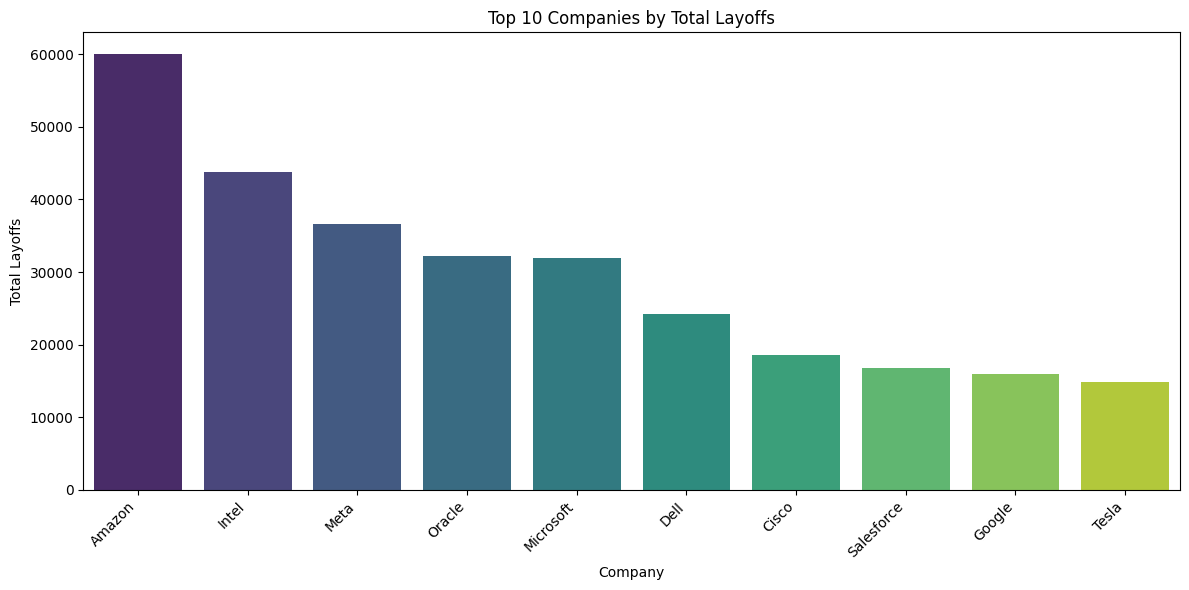

In [ ]:
# Top 10 companies by total_laid_off
top_companies = data.groupby('company')['total_laid_off'].sum().nlargest(10).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_companies.index, y=top_companies.values, palette='viridis')
plt.title('Top 10 Companies by Total Layoffs')
plt.xlabel('Company')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Next, let's look at the trend of layoffs over time, specifically by year.

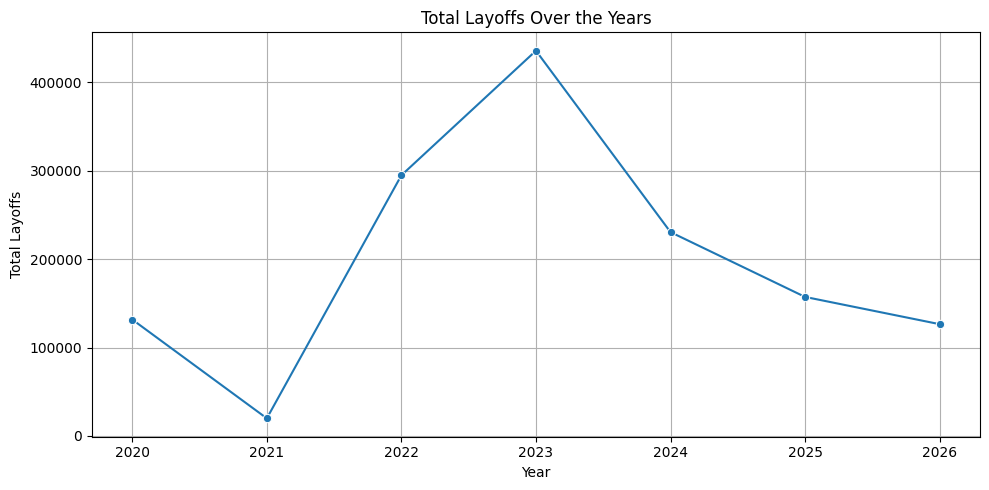

In [ ]:
# Layoffs trend over time (by year)
layoffs_by_year = data.groupby('year')['total_laid_off'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='year', y='total_laid_off', data=layoffs_by_year, marker='o')
plt.title('Total Layoffs Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Layoffs')
plt.grid(True)
plt.xticks(layoffs_by_year['year'].unique())
plt.tight_layout()
plt.show()

Let's also look at the total layoffs by industry to identify which sectors have been most affected.

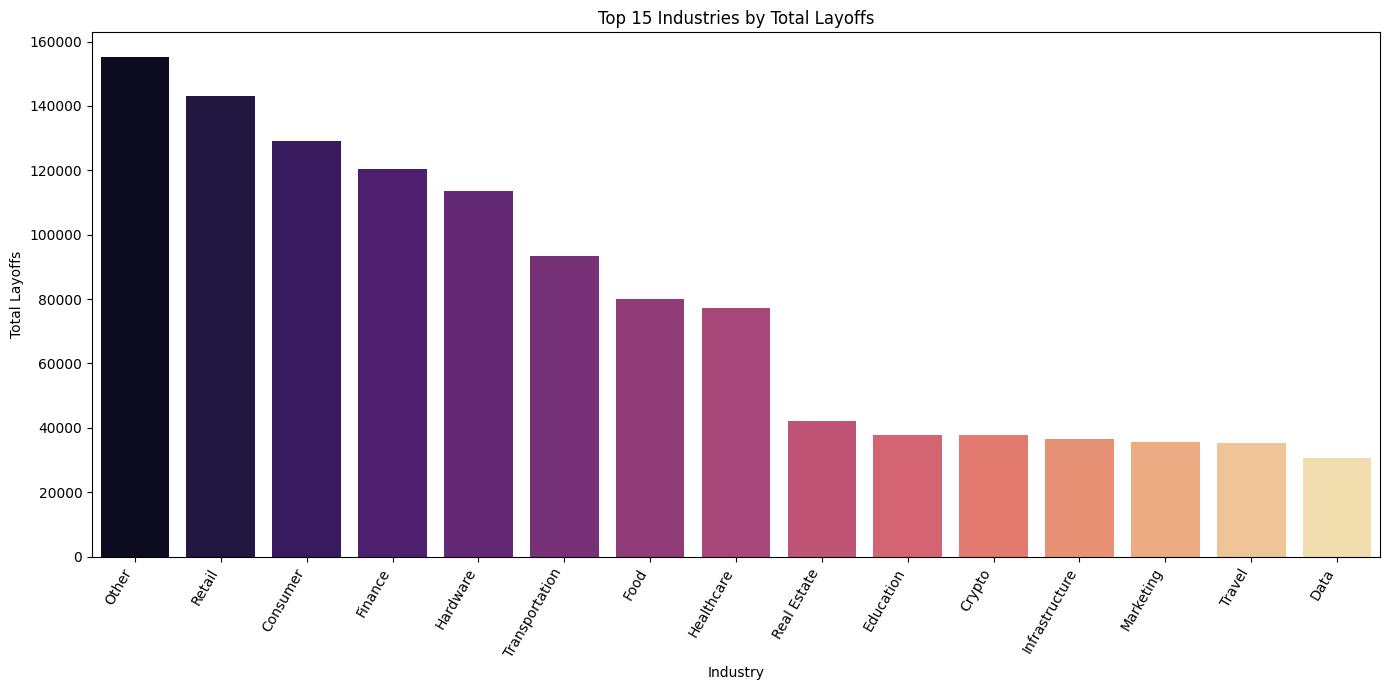

In [ ]:
# Total layoffs by industry
layoffs_by_industry = data.groupby('industry')['total_laid_off'].sum().nlargest(15).sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=layoffs_by_industry.index, y=layoffs_by_industry.values, palette='magma')
plt.title('Top 15 Industries by Total Layoffs')
plt.xlabel('Industry')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Now, let's analyze the total layoffs by country to see which regions have been most impacted.

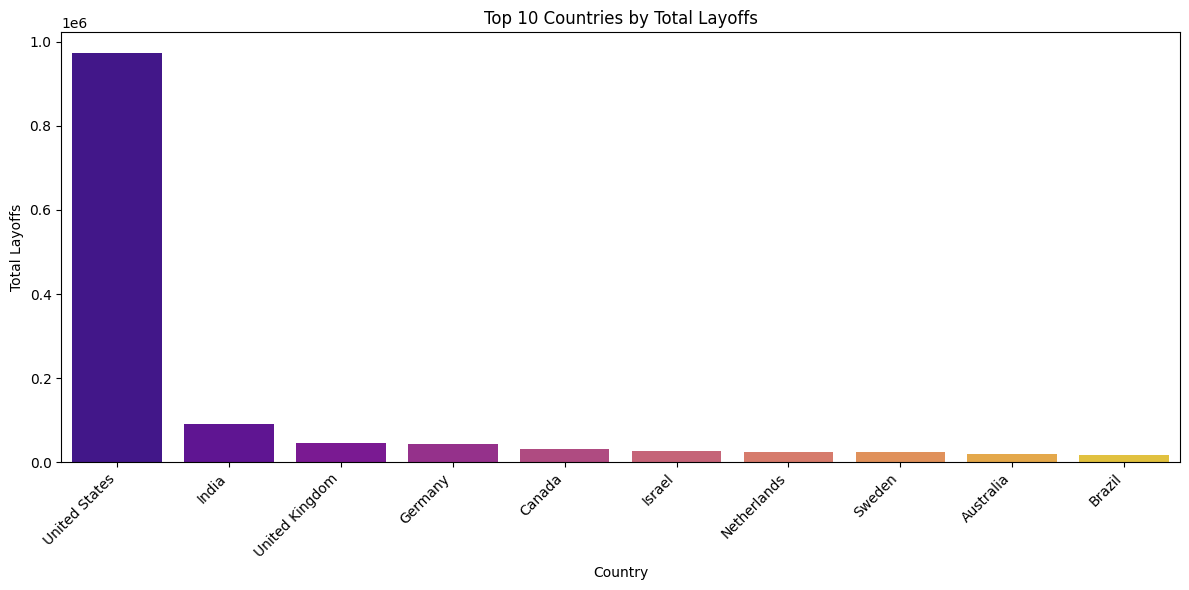

In [ ]:
# Total layoffs by country
layoffs_by_country = data.groupby('country')['total_laid_off'].sum().nlargest(10).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=layoffs_by_country.index, y=layoffs_by_country.values, palette='plasma')
plt.title('Top 10 Countries by Total Layoffs')
plt.xlabel('Country')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's examine the distribution of `total_laid_off` and `percentage_laid_off` to understand their characteristics.

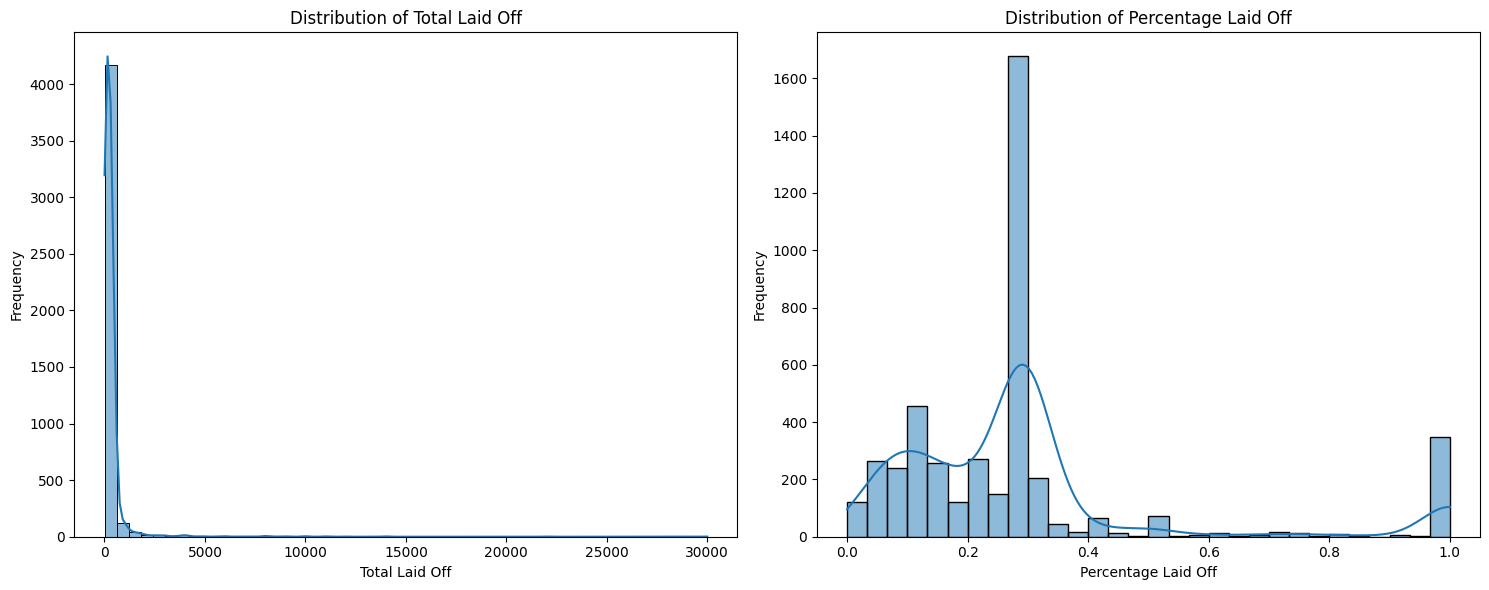

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data['total_laid_off'], bins=50, kde=True)
plt.title('Distribution of Total Laid Off')
plt.xlabel('Total Laid Off')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(data['percentage_laid_off'], bins=30, kde=True)
plt.title('Distribution of Percentage Laid Off')
plt.xlabel('Percentage Laid Off')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

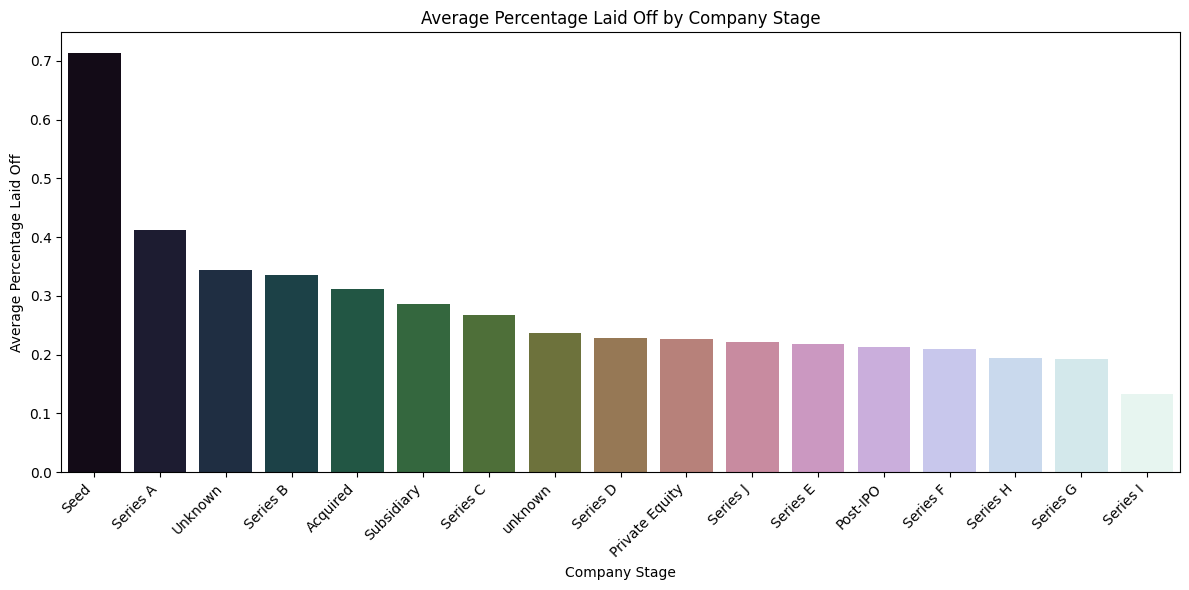

In [ ]:
# Average percentage laid off by stage
layoffs_by_stage = data.groupby('stage')['percentage_laid_off'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=layoffs_by_stage.index, y=layoffs_by_stage.values, palette='cubehelix')
plt.title('Average Percentage Laid Off by Company Stage')
plt.xlabel('Company Stage')
plt.ylabel('Average Percentage Laid Off')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()